In [1]:
# Import libraries for data loading, preprocessing, modeling, evaluation, and saving the model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

print("Baseline modeling environment ready")

Baseline modeling environment ready


In [2]:
# Load the processed modeling dataset created in the EDA notebook

path = "../data/processed/denial_risk_modeling_sample_250k.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(250000, 24)


,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary,high_charge_allowed_ratio,low_payment_charge_ratio,high_service_intensity,risk_score,denial_risk_proxy
0,1003882531,UT,Family Practice,Y,77067,Screening mammography,N,O,11,11.0,11,325.660000,84.184545,84.184545,90.226364,3.868406,0.258504,1.000000,1.000000,0,0,0,0,0
1,1992254726,TX,Nurse Practitioner,Y,87804,Detection test by immunoassay with direct visu...,N,O,11,11.0,11,50.000000,16.220000,16.220000,16.220000,3.082614,0.324400,1.000000,1.000000,0,0,0,0,0
2,1750657938,PA,Emergency Medicine,Y,99285,Emergency department visit with high level of ...,N,F,51,51.0,51,1377.980392,172.981765,133.733333,130.515294,7.966044,0.097050,0.773107,1.000000,1,1,0,2,1
3,1205611712,FL,Nurse Practitioner,Y,99350,Residence visit for established patient with h...,N,O,56,75.0,75,180.900000,154.000000,122.700000,122.450000,1.174675,0.678275,0.796753,1.339286,0,0,0,0,0
4,1023763927,MD,Physical Therapist in Private Practice,Y,97110,Therapy procedure using exercise to develop st...,N,O,77,917.0,811,75.000000,28.049662,21.247874,19.097012,2.673829,0.283305,0.757509,11.909091,0,0,1,1,0


In [3]:
# check how many low risk/ high risk 
df["denial_risk_proxy"].value_counts()

denial_risk_proxy
0    190698
1     59302
Name: count, dtype: int64

In [4]:
# Check the percentage split for the proxy denial-risk label

df["denial_risk_proxy"].value_counts(normalize=True)

denial_risk_proxy
0    0.762792
1    0.237208
Name: proportion, dtype: float64

In [5]:
# Select useful features for the first baseline model and define the target variable

features = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code",
    "is_drug",
    "place_of_service",
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount",
    "charge_to_allowed_ratio",
    "payment_to_charge_ratio",
    "payment_to_allowed_ratio",
    "services_per_beneficiary"
]

target = "denial_risk_proxy"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(250000, 17)
(250000,)


## Model B: Less-Leaky Baseline Model

The first Random Forest model included engineered reimbursement ratio features that were also used to create the proxy denial-risk label. This second model removes those direct proxy-label inputs and uses only provider, service, volume, and reimbursement amount fields.

This gives a more realistic test of whether available CMS features can estimate reimbursement-risk patterns without directly reusing the same fields that created the label.


In [20]:
# Define a less-leaky feature set by removing direct proxy-label input features

features_less_leaky = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code",
    "is_drug",
    "place_of_service",
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount"
]

target = "denial_risk_proxy"

features_less_leaky_df = df[features_less_leaky].copy()
target_less_leaky = df[target].copy()

print(features_less_leaky_df.shape)
print(target_less_leaky.shape)


(250000, 13)
(250000,)


In [21]:
# Separate categorical and numeric features for the less-leaky model

categorical_features_less_leaky = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code",
    "is_drug",
    "place_of_service"
]

numeric_features_less_leaky = [
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount"
]

print("Categorical features:", len(categorical_features_less_leaky))
print("Numeric features:", len(numeric_features_less_leaky))


Categorical features: 6
Numeric features: 7


In [22]:
# Split the less-leaky feature set into training and test data while preserving the class balance

features_train_less_leaky, features_test_less_leaky, target_train_less_leaky, target_test_less_leaky = train_test_split(
    features_less_leaky_df,
    target_less_leaky,
    test_size=0.2,
    random_state=42,
    stratify=target_less_leaky
)

print(features_train_less_leaky.shape)
print(features_test_less_leaky.shape)
print(target_train_less_leaky.value_counts(normalize=True))
print(target_test_less_leaky.value_counts(normalize=True))


(200000, 13)
(50000, 13)
denial_risk_proxy
0    0.76279
1    0.23721
Name: proportion, dtype: float64
denial_risk_proxy
0    0.7628
1    0.2372
Name: proportion, dtype: float64


In [23]:
# Build the preprocessing and Random Forest pipeline for the less-leaky model

preprocessor_less_leaky = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_less_leaky),
        ("num", "passthrough", numeric_features_less_leaky)
    ]
)

less_leaky_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

less_leaky_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_less_leaky),
        ("model", less_leaky_model)
    ]
)

less_leaky_pipeline


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Train the less-leaky Random Forest model

less_leaky_pipeline.fit(features_train_less_leaky, target_train_less_leaky)

print("Less-leaky model training complete")


Less-leaky model training complete


In [25]:
# Generate predictions and high-risk probabilities for the less-leaky model

target_pred_less_leaky = less_leaky_pipeline.predict(features_test_less_leaky)
target_proba_less_leaky = less_leaky_pipeline.predict_proba(features_test_less_leaky)[:, 1]

print("Less-leaky predictions complete")


Less-leaky predictions complete


In [26]:
# Evaluate the less-leaky model using standard classification metrics

accuracy_less_leaky = accuracy_score(target_test_less_leaky, target_pred_less_leaky)
precision_less_leaky = precision_score(target_test_less_leaky, target_pred_less_leaky)
recall_less_leaky = recall_score(target_test_less_leaky, target_pred_less_leaky)
f1_less_leaky = f1_score(target_test_less_leaky, target_pred_less_leaky)
roc_auc_less_leaky = roc_auc_score(target_test_less_leaky, target_proba_less_leaky)

print(f"Accuracy:  {accuracy_less_leaky:.4f}")
print(f"Precision: {precision_less_leaky:.4f}")
print(f"Recall:    {recall_less_leaky:.4f}")
print(f"F1 Score:  {f1_less_leaky:.4f}")
print(f"ROC AUC:   {roc_auc_less_leaky:.4f}")


Accuracy:  0.7719
Precision: 0.5129
Recall:    0.7646
F1 Score:  0.6139
ROC AUC:   0.8514


In [27]:
# Display detailed class-level performance for the less-leaky model

print(classification_report(target_test_less_leaky, target_pred_less_leaky))


              precision    recall  f1-score   support

           0       0.91      0.77      0.84     38140
           1       0.51      0.76      0.61     11860

    accuracy                           0.77     50000
   macro avg       0.71      0.77      0.73     50000
weighted avg       0.82      0.77      0.78     50000



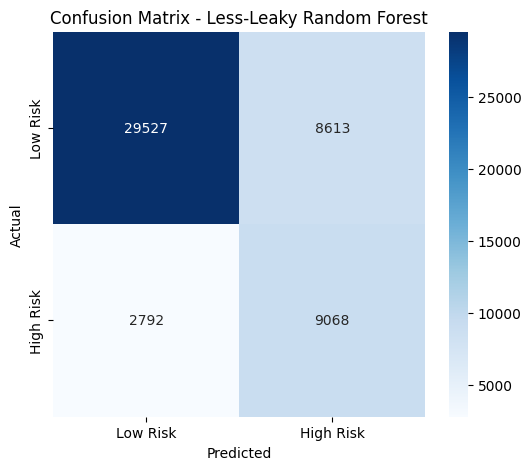

In [28]:
# Plot the confusion matrix for the less-leaky model

cm_less_leaky = confusion_matrix(target_test_less_leaky, target_pred_less_leaky)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_less_leaky,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title("Confusion Matrix - Less-Leaky Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [29]:
# Extract one-hot encoded feature names so less-leaky feature importance can be interpreted

cat_feature_names_less_leaky = (
    less_leaky_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features_less_leaky)
)

all_feature_names_less_leaky = list(cat_feature_names_less_leaky) + numeric_features_less_leaky

print("Total transformed features:", len(all_feature_names_less_leaky))


Total transformed features: 3379


In [30]:
# Create a feature importance table for the less-leaky Random Forest model

feature_importance_df_less_leaky = pd.DataFrame({
    "feature": all_feature_names_less_leaky,
    "importance": less_leaky_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df_less_leaky.head(20)


,feature,importance
3375,avg_submitted_charge,0.159850
3371,place_of_service_O,0.128410
3370,place_of_service_F,0.111547
3377,avg_medicare_payment_amount,0.057608
3378,avg_medicare_standardized_amount,0.045870
3376,avg_medicare_allowed_amount,0.038946
84,provider_type_Diagnostic Radiology,0.030949
2851,hcpcs_code_99214,0.023810
2850,hcpcs_code_99213,0.023434
67,provider_type_Anesthesiology,0.022941


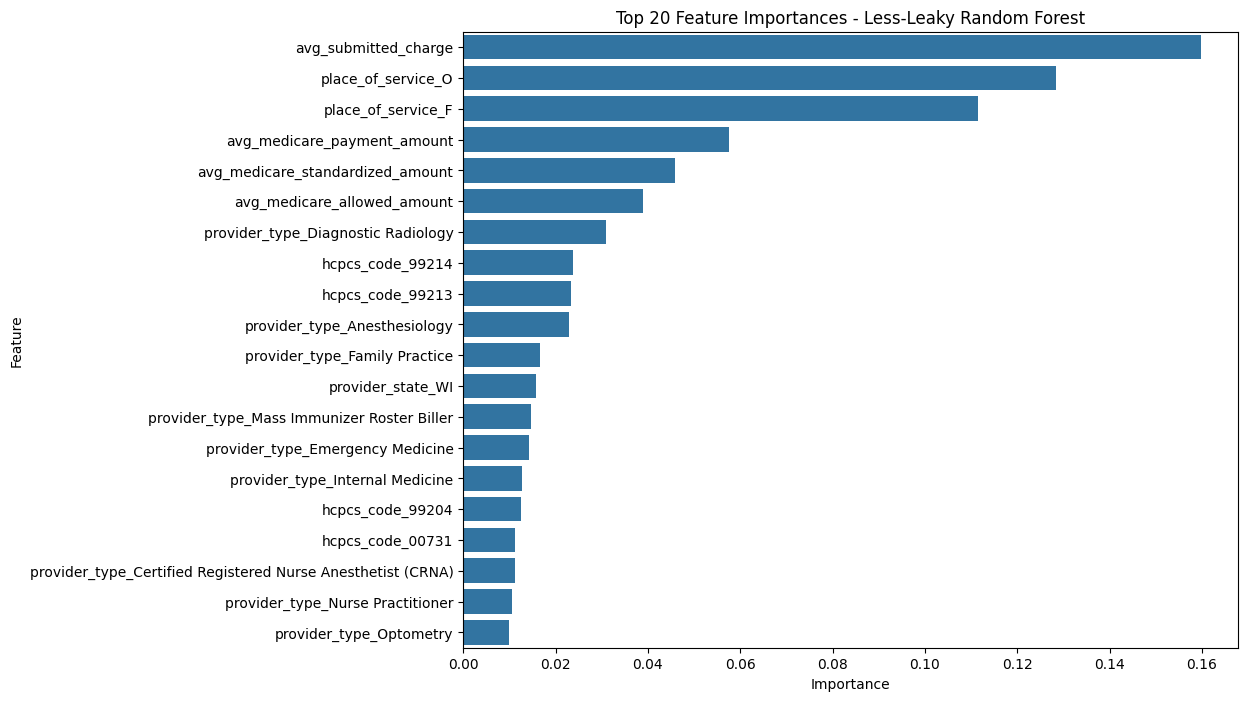

In [31]:
# Plot the top 20 most important features for the less-leaky model

top_features_less_leaky = feature_importance_df_less_leaky.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features_less_leaky,
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances - Less-Leaky Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [32]:
# Save the less-leaky Random Forest pipeline for future app or API use

less_leaky_model_path = "../models/less_leaky_rf_denial_risk_model.joblib"

joblib.dump(less_leaky_pipeline, less_leaky_model_path)

print(f"Less-leaky model saved to {less_leaky_model_path}")


Less-leaky model saved to ../models/less_leaky_rf_denial_risk_model.joblib


In [33]:
# Save the less-leaky model feature importance results for reporting

feature_importance_df_less_leaky.to_csv(
    "../reports/less_leaky_rf_feature_importance.csv",
    index=False
)

print("Less-leaky feature importance saved successfully")


Less-leaky feature importance saved successfully


In [34]:
# Save less-leaky model test predictions for later error analysis

less_leaky_predictions_df = features_test_less_leaky.copy()
less_leaky_predictions_df["actual_denial_risk_proxy"] = target_test_less_leaky.values
less_leaky_predictions_df["predicted_denial_risk_proxy"] = target_pred_less_leaky
less_leaky_predictions_df["predicted_high_risk_probability"] = target_proba_less_leaky

less_leaky_predictions_df.to_csv(
    "../reports/less_leaky_rf_test_predictions.csv",
    index=False
)

print("Less-leaky test predictions saved successfully")


Less-leaky test predictions saved successfully


## Model Comparison

This section compares the original workflow-validation model against the less-leaky model. The workflow-validation model is useful for proving the end-to-end pipeline works. The less-leaky model is more realistic because it removes the direct ratio features used to create the proxy label.


In [35]:
# Compare Model A and Model B metrics in one table

model_comparison_df = pd.DataFrame({
    "model": [
        "Workflow Validation Random Forest",
        "Less-Leaky Random Forest"
    ],
    "accuracy": [
        accuracy,
        accuracy_less_leaky
    ],
    "precision": [
        precision,
        precision_less_leaky
    ],
    "recall": [
        recall,
        recall_less_leaky
    ],
    "f1_score": [
        f1,
        f1_less_leaky
    ],
    "roc_auc": [
        roc_auc,
        roc_auc_less_leaky
    ]
})

model_comparison_df


,model,accuracy,precision,recall,f1_score,roc_auc
0,Workflow Validation Random Forest,0.98318,0.949645,0.981113,0.965123,0.998726
1,Less-Leaky Random Forest,0.77190,0.512867,0.764587,0.613926,0.851382


In [36]:
# Save model comparison results for project reporting

model_comparison_df.to_csv("../reports/model_comparison.csv", index=False)

print("Model comparison saved successfully")


Model comparison saved successfully


## Model B Improvements: Threshold Tuning and Safer Feature Engineering

This section improves the less-leaky model without adding the direct proxy-label features back into the model.

The goal is to improve business usefulness by:

- tuning the high-risk prediction threshold
- adding safer log-transformed numeric features
- grouping rare HCPCS codes to reduce noise
- training an improved Random Forest model
- comparing baseline Model B against the improved Model B

For this use case, recall is especially important because the dashboard is meant to flag claims for review before submission.

In [37]:
# Create output folders if they do not already exist

import os
import json

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

print("Output folders are ready")

Output folders are ready


In [38]:
# Tune the decision threshold for the existing less-leaky Random Forest model

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    threshold_pred = (target_proba_less_leaky >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(target_test_less_leaky, threshold_pred),
        "recall": recall_score(target_test_less_leaky, threshold_pred),
        "f1_score": f1_score(target_test_less_leaky, threshold_pred)
    })

threshold_df_less_leaky = pd.DataFrame(threshold_results)

threshold_df_less_leaky

,threshold,precision,recall,f1_score
0,0.30,0.243661,0.999916,0.391839
1,0.35,0.286905,0.992580,0.445142
2,0.40,0.372938,0.934233,0.533077
3,0.45,0.427735,0.849916,0.569074
4,0.50,0.512867,0.764587,0.613926
5,0.55,0.583802,0.629680,0.605874
6,0.60,0.682288,0.450506,0.542684
7,0.65,0.890616,0.260877,0.403548
8,0.70,0.975260,0.063153,0.118625


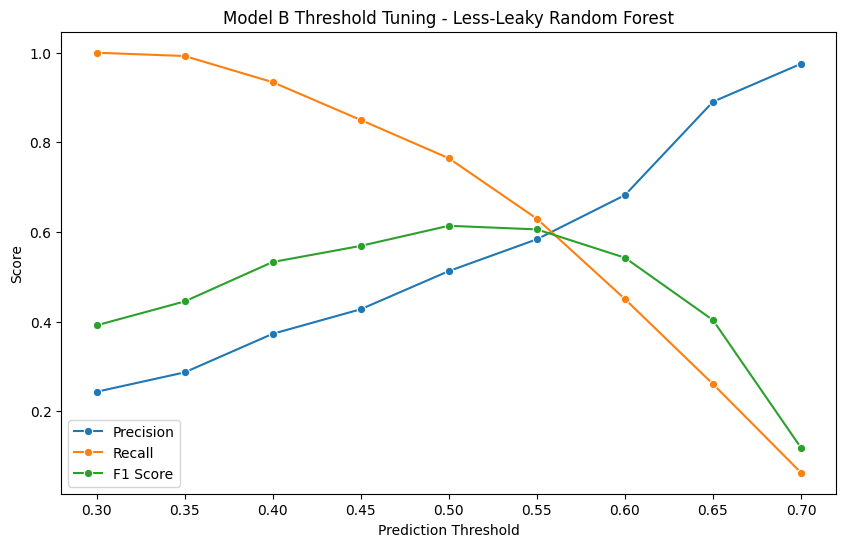

In [39]:
# Plot precision, recall, and F1 score across thresholds for the existing less-leaky model

plt.figure(figsize=(10, 6))

sns.lineplot(data=threshold_df_less_leaky, x="threshold", y="precision", marker="o", label="Precision")
sns.lineplot(data=threshold_df_less_leaky, x="threshold", y="recall", marker="o", label="Recall")
sns.lineplot(data=threshold_df_less_leaky, x="threshold", y="f1_score", marker="o", label="F1 Score")

plt.title("Model B Threshold Tuning - Less-Leaky Random Forest")
plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [40]:
# Choose the best threshold for the existing less-leaky model based on F1 score

best_threshold_row_less_leaky = threshold_df_less_leaky.sort_values("f1_score", ascending=False).iloc[0]
best_threshold_less_leaky = best_threshold_row_less_leaky["threshold"]

best_threshold_row_less_leaky

threshold    0.500000
precision    0.512867
recall       0.764587
f1_score     0.613926
Name: 4, dtype: float64

In [41]:
# Evaluate the existing less-leaky model using the best threshold instead of the default 0.50 threshold

best_threshold_pred_less_leaky = (target_proba_less_leaky >= best_threshold_less_leaky).astype(int)

accuracy_less_leaky_threshold = accuracy_score(target_test_less_leaky, best_threshold_pred_less_leaky)
precision_less_leaky_threshold = precision_score(target_test_less_leaky, best_threshold_pred_less_leaky)
recall_less_leaky_threshold = recall_score(target_test_less_leaky, best_threshold_pred_less_leaky)
f1_less_leaky_threshold = f1_score(target_test_less_leaky, best_threshold_pred_less_leaky)
roc_auc_less_leaky_threshold = roc_auc_score(target_test_less_leaky, target_proba_less_leaky)

print(f"Best Threshold: {best_threshold_less_leaky:.2f}")
print(f"Accuracy:  {accuracy_less_leaky_threshold:.4f}")
print(f"Precision: {precision_less_leaky_threshold:.4f}")
print(f"Recall:    {recall_less_leaky_threshold:.4f}")
print(f"F1 Score:  {f1_less_leaky_threshold:.4f}")
print(f"ROC AUC:   {roc_auc_less_leaky_threshold:.4f}")

Best Threshold: 0.50
Accuracy:  0.7719
Precision: 0.5129
Recall:    0.7646
F1 Score:  0.6139
ROC AUC:   0.8514


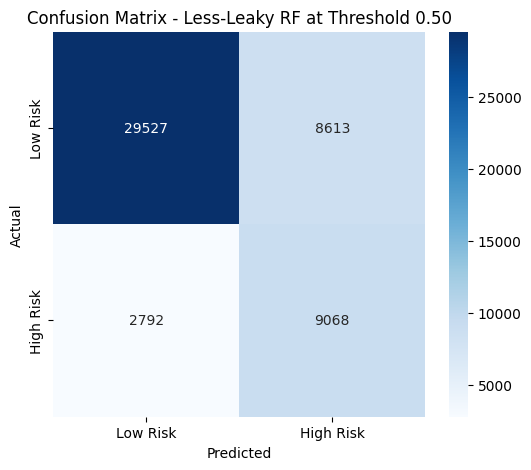

In [42]:
# Plot the confusion matrix for the threshold-tuned less-leaky model

cm_less_leaky_threshold = confusion_matrix(target_test_less_leaky, best_threshold_pred_less_leaky)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_less_leaky_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title(f"Confusion Matrix - Less-Leaky RF at Threshold {best_threshold_less_leaky:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Improved Model B: Log Features + Grouped HCPCS Codes

This version keeps the model less leaky by still excluding the direct proxy-label inputs:

- `charge_to_allowed_ratio`
- `payment_to_charge_ratio`
- `payment_to_allowed_ratio`
- `services_per_beneficiary`

It adds safer improvements:

- log-transformed charge, payment, and volume fields
- grouped HCPCS codes so rare codes are treated as `OTHER_HCPCS`
- a stronger Random Forest configuration

In [43]:
# Create train and test copies for improved Model B feature engineering

features_train_improved = features_train_less_leaky.copy()
features_test_improved = features_test_less_leaky.copy()

print(features_train_improved.shape)
print(features_test_improved.shape)

(200000, 13)
(50000, 13)


In [44]:
# Group rare HCPCS codes using only the training data to avoid test-set information leakage

top_hcpcs_codes = (
    features_train_improved["hcpcs_code"]
    .value_counts()
    .head(300)
    .index
)

features_train_improved["hcpcs_code_grouped"] = np.where(
    features_train_improved["hcpcs_code"].isin(top_hcpcs_codes),
    features_train_improved["hcpcs_code"],
    "OTHER_HCPCS"
)

features_test_improved["hcpcs_code_grouped"] = np.where(
    features_test_improved["hcpcs_code"].isin(top_hcpcs_codes),
    features_test_improved["hcpcs_code"],
    "OTHER_HCPCS"
)

features_train_improved["hcpcs_code_grouped"].value_counts().head()

hcpcs_code_grouped
OTHER_HCPCS    41148
99214          10577
99213           9579
99204           4763
99232           3599
Name: count, dtype: int64

In [45]:
# Add safer log-transformed numeric features to reduce the impact of skewed healthcare payment values

log_feature_source_cols = [
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount"
]

for col in log_feature_source_cols:
    features_train_improved[f"log_{col}"] = np.log1p(features_train_improved[col])
    features_test_improved[f"log_{col}"] = np.log1p(features_test_improved[col])

features_train_improved.head()

,provider_state,provider_type,medicare_participating,hcpcs_code,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,hcpcs_code_grouped,log_total_beneficiaries,log_total_services,log_total_beneficiary_day_services,log_avg_submitted_charge,log_avg_medicare_allowed_amount,log_avg_medicare_payment_amount,log_avg_medicare_standardized_amount
61820,TN,Orthopedic Surgery,Y,99204,N,O,12,12.0,12,468.000000,152.582500,111.390000,120.281667,99204,2.564949,2.564949,2.564949,6.150603,5.034238,4.721975,4.798116
57353,NE,Physical Therapist in Private Practice,Y,97162,N,O,19,22.0,22,190.000000,92.943182,61.779091,65.925909,97162,2.995732,3.135494,3.135494,5.252273,4.542690,4.139622,4.203586
67339,FL,Nurse Practitioner,Y,99204,N,O,66,66.0,66,233.280000,139.723788,84.804394,84.771212,99204,4.204693,4.204693,4.204693,5.456517,4.946799,4.452070,4.451683
215316,OH,Anesthesiology,Y,01630,N,F,28,28.0,28,678.321429,105.056071,83.702500,84.740357,OTHER_HCPCS,3.367296,3.367296,3.367296,6.521094,4.663968,4.439145,4.451324
30007,CT,"Psychologist, Clinical",Y,96132,N,F,11,11.0,11,357.000000,107.240000,85.540000,81.950000,OTHER_HCPCS,2.484907,2.484907,2.484907,5.880533,4.684351,4.460607,4.418238


In [46]:
# Define the improved less-leaky feature set with grouped HCPCS and log-transformed numeric features

categorical_features_improved = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code_grouped",
    "is_drug",
    "place_of_service"
]

numeric_features_improved = [
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount",
    "log_total_beneficiaries",
    "log_total_services",
    "log_total_beneficiary_day_services",
    "log_avg_submitted_charge",
    "log_avg_medicare_allowed_amount",
    "log_avg_medicare_payment_amount",
    "log_avg_medicare_standardized_amount"
]

features_improved = categorical_features_improved + numeric_features_improved

features_train_improved = features_train_improved[features_improved].copy()
features_test_improved = features_test_improved[features_improved].copy()

print("Improved training features:", features_train_improved.shape)
print("Improved test features:", features_test_improved.shape)

Improved training features: (200000, 20)
Improved test features: (50000, 20)


In [47]:
# Build the improved less-leaky Random Forest pipeline

preprocessor_improved = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_improved),
        ("num", "passthrough", numeric_features_improved)
    ]
)

improved_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

improved_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_improved),
        ("model", improved_rf_model)
    ]
)

improved_rf_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
# Train the improved less-leaky Random Forest model

improved_rf_pipeline.fit(features_train_improved, target_train_less_leaky)

print("Improved less-leaky Random Forest training complete")

Improved less-leaky Random Forest training complete


In [49]:
# Generate predictions and high-risk probabilities for the improved less-leaky model

improved_pred_default = improved_rf_pipeline.predict(features_test_improved)
improved_proba = improved_rf_pipeline.predict_proba(features_test_improved)[:, 1]

print("Improved model predictions complete")

Improved model predictions complete


In [50]:
# Evaluate the improved less-leaky model using the default 0.50 threshold

accuracy_improved_default = accuracy_score(target_test_less_leaky, improved_pred_default)
precision_improved_default = precision_score(target_test_less_leaky, improved_pred_default)
recall_improved_default = recall_score(target_test_less_leaky, improved_pred_default)
f1_improved_default = f1_score(target_test_less_leaky, improved_pred_default)
roc_auc_improved = roc_auc_score(target_test_less_leaky, improved_proba)

print(f"Accuracy:  {accuracy_improved_default:.4f}")
print(f"Precision: {precision_improved_default:.4f}")
print(f"Recall:    {recall_improved_default:.4f}")
print(f"F1 Score:  {f1_improved_default:.4f}")
print(f"ROC AUC:   {roc_auc_improved:.4f}")

Accuracy:  0.9268
Precision: 0.7974
Recall:    0.9271
F1 Score:  0.8574
ROC AUC:   0.9834


In [51]:
# Tune the decision threshold for the improved less-leaky model

threshold_results_improved = []

for threshold in np.arange(0.30, 0.71, 0.05):
    threshold_pred = (improved_proba >= threshold).astype(int)
    
    threshold_results_improved.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(target_test_less_leaky, threshold_pred),
        "recall": recall_score(target_test_less_leaky, threshold_pred),
        "f1_score": f1_score(target_test_less_leaky, threshold_pred)
    })

threshold_df_improved = pd.DataFrame(threshold_results_improved)

threshold_df_improved

,threshold,precision,recall,f1_score
0,0.30,0.532565,0.997639,0.694427
1,0.35,0.603236,0.993255,0.750605
2,0.40,0.667411,0.983052,0.795049
3,0.45,0.725178,0.960708,0.826491
4,0.50,0.797433,0.927066,0.857377
5,0.55,0.861897,0.886678,0.874112
6,0.60,0.904111,0.836341,0.868906
7,0.65,0.942122,0.771332,0.848215
8,0.70,0.972701,0.684992,0.803879


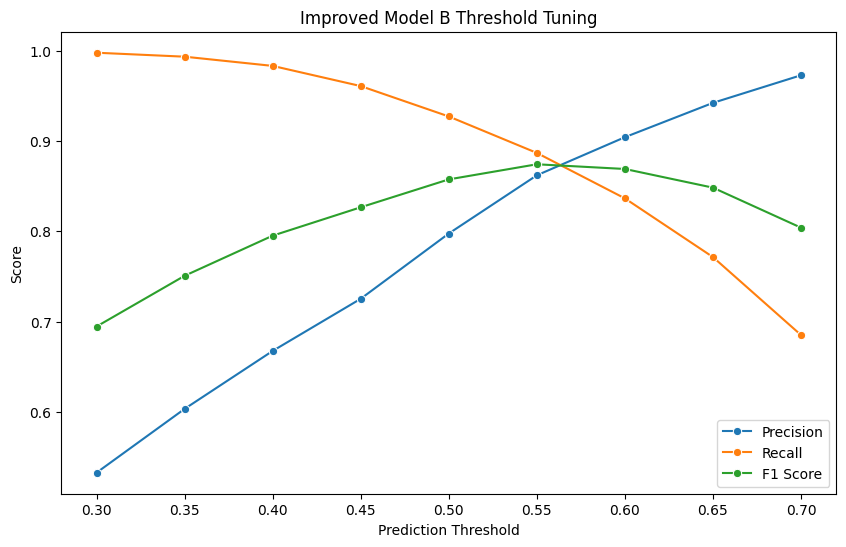

In [52]:
# Plot precision, recall, and F1 score across thresholds for the improved less-leaky model

plt.figure(figsize=(10, 6))

sns.lineplot(data=threshold_df_improved, x="threshold", y="precision", marker="o", label="Precision")
sns.lineplot(data=threshold_df_improved, x="threshold", y="recall", marker="o", label="Recall")
sns.lineplot(data=threshold_df_improved, x="threshold", y="f1_score", marker="o", label="F1 Score")

plt.title("Improved Model B Threshold Tuning")
plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [53]:
# Choose the best threshold for the improved model based on F1 score

best_threshold_row_improved = threshold_df_improved.sort_values("f1_score", ascending=False).iloc[0]
best_threshold_improved = best_threshold_row_improved["threshold"]

best_threshold_row_improved

threshold    0.550000
precision    0.861897
recall       0.886678
f1_score     0.874112
Name: 5, dtype: float64

In [54]:
# Evaluate the improved less-leaky model using the best threshold

improved_pred_threshold = (improved_proba >= best_threshold_improved).astype(int)

accuracy_improved_threshold = accuracy_score(target_test_less_leaky, improved_pred_threshold)
precision_improved_threshold = precision_score(target_test_less_leaky, improved_pred_threshold)
recall_improved_threshold = recall_score(target_test_less_leaky, improved_pred_threshold)
f1_improved_threshold = f1_score(target_test_less_leaky, improved_pred_threshold)
roc_auc_improved_threshold = roc_auc_score(target_test_less_leaky, improved_proba)

print(f"Best Threshold: {best_threshold_improved:.2f}")
print(f"Accuracy:  {accuracy_improved_threshold:.4f}")
print(f"Precision: {precision_improved_threshold:.4f}")
print(f"Recall:    {recall_improved_threshold:.4f}")
print(f"F1 Score:  {f1_improved_threshold:.4f}")
print(f"ROC AUC:   {roc_auc_improved_threshold:.4f}")

Best Threshold: 0.55
Accuracy:  0.9394
Precision: 0.8619
Recall:    0.8867
F1 Score:  0.8741
ROC AUC:   0.9834


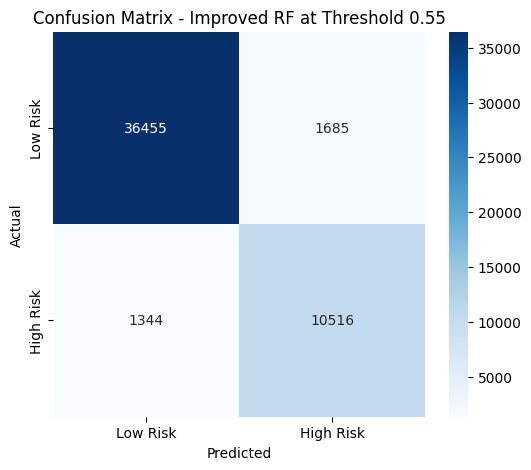

In [55]:
# Plot the confusion matrix for the improved model at the best threshold

cm_improved_threshold = confusion_matrix(target_test_less_leaky, improved_pred_threshold)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_improved_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title(f"Confusion Matrix - Improved RF at Threshold {best_threshold_improved:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
# Extract feature names and create feature importance results for the improved model

cat_feature_names_improved = (
    improved_rf_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features_improved)
)

all_feature_names_improved = list(cat_feature_names_improved) + numeric_features_improved

feature_importance_df_improved = pd.DataFrame({
    "feature": all_feature_names_improved,
    "importance": improved_rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df_improved.head(20)

,feature,importance
482,log_avg_submitted_charge,0.221137
475,avg_submitted_charge,0.207116
477,avg_medicare_payment_amount,0.048921
476,avg_medicare_allowed_amount,0.048109
483,log_avg_medicare_allowed_amount,0.046078
484,log_avg_medicare_payment_amount,0.045588
471,place_of_service_O,0.044875
478,avg_medicare_standardized_amount,0.044176
470,place_of_service_F,0.043654
485,log_avg_medicare_standardized_amount,0.043224


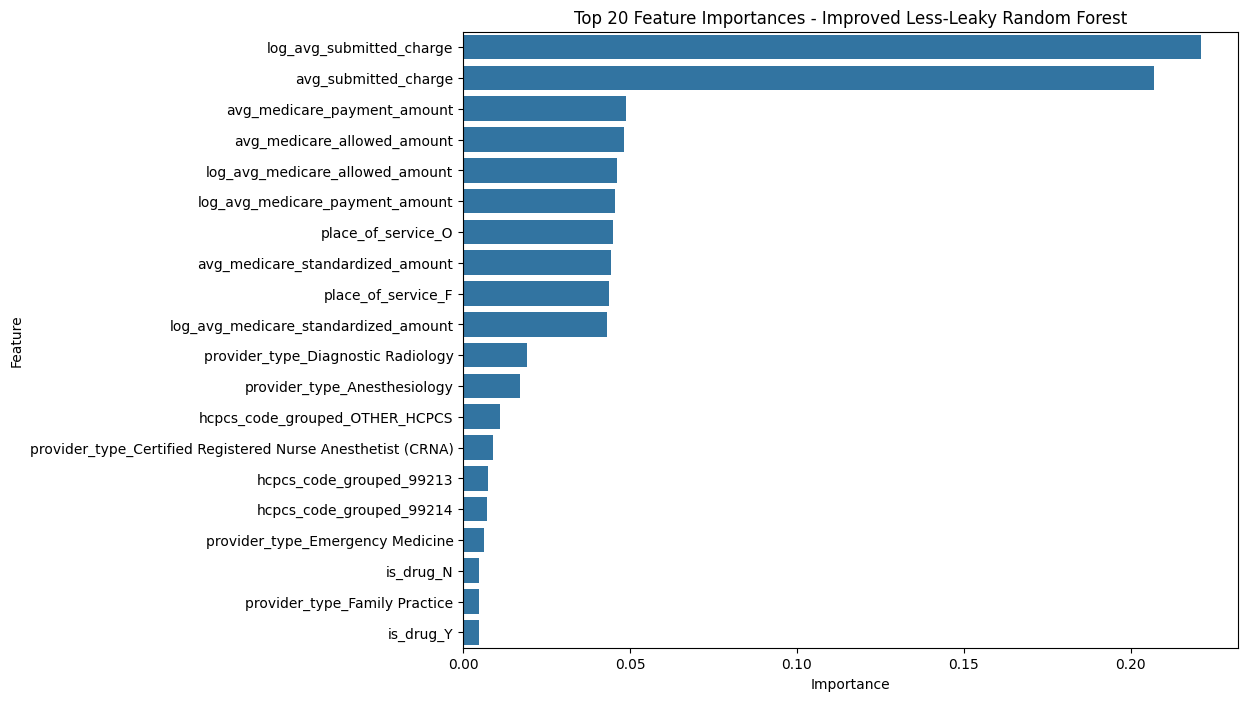

In [57]:
# Plot the top 20 most important features for the improved less-leaky model

top_features_improved = feature_importance_df_improved.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features_improved,
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances - Improved Less-Leaky Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [58]:
# Save the improved less-leaky Random Forest model and its threshold for app/API use

improved_model_path = "../models/improved_less_leaky_rf_denial_risk_model.joblib"
improved_threshold_path = "../models/improved_less_leaky_rf_threshold.json"

joblib.dump(improved_rf_pipeline, improved_model_path)

with open(improved_threshold_path, "w") as f:
    json.dump({"threshold": float(best_threshold_improved)}, f)

print(f"Improved model saved to {improved_model_path}")
print(f"Improved threshold saved to {improved_threshold_path}")

Improved model saved to ../models/improved_less_leaky_rf_denial_risk_model.joblib
Improved threshold saved to ../models/improved_less_leaky_rf_threshold.json


In [59]:
# Save improved feature importance and threshold results for reporting

feature_importance_df_improved.to_csv(
    "../reports/improved_less_leaky_rf_feature_importance.csv",
    index=False
)

threshold_df_improved.to_csv(
    "../reports/improved_less_leaky_rf_threshold_results.csv",
    index=False
)

print("Improved feature importance and threshold results saved successfully")

Improved feature importance and threshold results saved successfully


In [60]:
# Save improved model test predictions for error analysis

improved_predictions_df = features_test_improved.copy()
improved_predictions_df["actual_denial_risk_proxy"] = target_test_less_leaky.values
improved_predictions_df["predicted_denial_risk_proxy_default"] = improved_pred_default
improved_predictions_df["predicted_denial_risk_proxy_threshold"] = improved_pred_threshold
improved_predictions_df["predicted_high_risk_probability"] = improved_proba

improved_predictions_df.to_csv(
    "../reports/improved_less_leaky_rf_test_predictions.csv",
    index=False
)

print("Improved test predictions saved successfully")

Improved test predictions saved successfully


## Updated Model Comparison

This comparison includes:

- Model A: workflow-validation Random Forest
- Model B: less-leaky Random Forest at default threshold
- Model B: threshold-tuned less-leaky Random Forest
- Improved Model B: log features, grouped HCPCS, and threshold tuning

For the dashboard, the best candidate is usually the improved less-leaky model because it avoids direct proxy-label leakage while giving better business control through threshold tuning.

In [61]:
# Compare all model versions in one table

updated_model_comparison_df = pd.DataFrame({
    "model": [
        "Workflow Validation Random Forest",
        "Less-Leaky Random Forest Default Threshold",
        "Less-Leaky Random Forest Tuned Threshold",
        "Improved Less-Leaky Random Forest Default Threshold",
        "Improved Less-Leaky Random Forest Tuned Threshold"
    ],
    "threshold": [
        0.50,
        0.50,
        best_threshold_less_leaky,
        0.50,
        best_threshold_improved
    ],
    "accuracy": [
        accuracy,
        accuracy_less_leaky,
        accuracy_less_leaky_threshold,
        accuracy_improved_default,
        accuracy_improved_threshold
    ],
    "precision": [
        precision,
        precision_less_leaky,
        precision_less_leaky_threshold,
        precision_improved_default,
        precision_improved_threshold
    ],
    "recall": [
        recall,
        recall_less_leaky,
        recall_less_leaky_threshold,
        recall_improved_default,
        recall_improved_threshold
    ],
    "f1_score": [
        f1,
        f1_less_leaky,
        f1_less_leaky_threshold,
        f1_improved_default,
        f1_improved_threshold
    ],
    "roc_auc": [
        roc_auc,
        roc_auc_less_leaky,
        roc_auc_less_leaky_threshold,
        roc_auc_improved,
        roc_auc_improved_threshold
    ]
})

updated_model_comparison_df.sort_values("f1_score", ascending=False)

,model,threshold,accuracy,precision,recall,f1_score,roc_auc
0,Workflow Validation Random Forest,0.50,0.98318,0.949645,0.981113,0.965123,0.998726
4,Improved Less-Leaky Random Forest Tuned Threshold,0.55,0.93942,0.861897,0.886678,0.874112,0.983403
3,Improved Less-Leaky Random Forest Default Thre...,0.50,0.92684,0.797433,0.927066,0.857377,0.983403
2,Less-Leaky Random Forest Tuned Threshold,0.50,0.77190,0.512867,0.764587,0.613926,0.851382
1,Less-Leaky Random Forest Default Threshold,0.50,0.77190,0.512867,0.764587,0.613926,0.851382


In [62]:
# Save the updated model comparison table

updated_model_comparison_df.to_csv("../reports/updated_model_comparison.csv", index=False)

print("Updated model comparison saved successfully")

Updated model comparison saved successfully


In [63]:
# Save the improved less-leaky model as the current production candidate for the Streamlit dashboard

production_model_path = "../models/production_denial_risk_model.joblib"
production_threshold_path = "../models/production_threshold.json"

joblib.dump(improved_rf_pipeline, production_model_path)

with open(production_threshold_path, "w") as f:
    json.dump({"threshold": float(best_threshold_improved)}, f)

print(f"Production candidate model saved to {production_model_path}")
print(f"Production threshold saved to {production_threshold_path}")

Production candidate model saved to ../models/production_denial_risk_model.joblib
Production threshold saved to ../models/production_threshold.json


## Project Note

The improved model is still trained on a proxy denial-risk label, not true denial outcomes. The value of this notebook is that it builds a practical denial-risk scoring workflow using public CMS data. In a real clinic or hospital deployment, the next step would be to replace the proxy target with actual denial outcomes from billing or revenue-cycle data.